In [1]:
# import kagglehub

# path = kagglehub.dataset_download("ravalsmit/customer-segmentation-data")

# print("Path to dataset files:", path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Windows file path
file_path = "C:/Users/adigo/Desktop/Hobby/Data_analysis/customer_segmentation/customer_segmentation_data.csv"

# Linux File path
# file_path = "/home/adigo/data_analysis/Data_analysis/customer_segmentation/customer_segmentation_data.csv"
df = pd.read_csv(file_path)
df.head(10)

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2
5,60937,41,Female,Separated,Master's Degree,Uttar Pradesh,Nurse,87188,policy5,9/19/2020,Chat,policy1,570757,1106,Individual,Text,Text,Afternoon,English,Segment4
6,37676,55,Male,Single,Bachelor's Degree,Rajasthan,Manager,94891,policy3,07-04-2021,Chat,policy2,604069,3661,Group,In-Person Meeting,Text,Weekends,Mandarin,Segment5
7,54100,35,Male,Married,Master's Degree,Himachal Pradesh,Artist,61003,policy1,11-01-2021,Phone,policy3,418997,1148,Business,Email,Phone,Morning,English,Segment5
8,30476,43,Female,Single,Doctorate,Manipur,Salesperson,116249,policy1,9/20/2020,Mobile App,policy4,319423,2612,Business,In-Person Meeting,Text,Weekends,Mandarin,Segment2
9,39071,32,Female,Single,Master's Degree,Gujarat,Artist,49083,policy3,4/24/2020,Phone,policy1,701577,4595,Group,Phone,Email,Weekends,English,Segment2


In [4]:

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Customer ID                         53503 non-null  int64 
 1   Age                                 53503 non-null  int64 
 2   Gender                              53503 non-null  object
 3   Marital Status                      53503 non-null  object
 4   Education Level                     53503 non-null  object
 5   Geographic Information              53503 non-null  object
 6   Occupation                          53503 non-null  object
 7   Income Level                        53503 non-null  int64 
 8   Behavioral Data                     53503 non-null  object
 9   Purchase History                    53503 non-null  object
 10  Interactions with Customer Service  53503 non-null  object
 11  Insurance Products Owned            53503 non-null  ob

,Customer ID,Age,Income Level,Coverage Amount,Premium Amount
count,53503.000000,53503.000000,53503.000000,53503.000000,53503.000000
mean,52265.204998,44.140945,82768.324318,492580.789638,3023.702447
std,28165.000067,15.079486,36651.075670,268405.505571,1285.834295
min,1.000000,18.000000,20001.000000,50001.000000,500.000000
25%,28950.500000,32.000000,51568.500000,249613.500000,1817.000000
50%,55858.000000,43.000000,80719.000000,477261.000000,3194.000000
75%,76096.000000,57.000000,115973.500000,739124.000000,4311.500000
max,100000.000000,70.000000,149999.000000,1000000.000000,5000.000000


In [5]:
string_cols = df.select_dtypes(include='object').columns
df[string_cols] = df[string_cols].apply(lambda col: col.str.strip())

In [6]:
df['Purchase History'] = pd.to_datetime(df['Purchase History'],errors='raise',format='mixed')
df.head(10)

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,2018-04-10,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,2018-11-06,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,2021-06-05,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,2018-09-02,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,2018-09-10,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2
5,60937,41,Female,Separated,Master's Degree,Uttar Pradesh,Nurse,87188,policy5,2020-09-19,Chat,policy1,570757,1106,Individual,Text,Text,Afternoon,English,Segment4
6,37676,55,Male,Single,Bachelor's Degree,Rajasthan,Manager,94891,policy3,2021-07-04,Chat,policy2,604069,3661,Group,In-Person Meeting,Text,Weekends,Mandarin,Segment5
7,54100,35,Male,Married,Master's Degree,Himachal Pradesh,Artist,61003,policy1,2021-11-01,Phone,policy3,418997,1148,Business,Email,Phone,Morning,English,Segment5
8,30476,43,Female,Single,Doctorate,Manipur,Salesperson,116249,policy1,2020-09-20,Mobile App,policy4,319423,2612,Business,In-Person Meeting,Text,Weekends,Mandarin,Segment2
9,39071,32,Female,Single,Master's Degree,Gujarat,Artist,49083,policy3,2020-04-24,Phone,policy1,701577,4595,Group,Phone,Email,Weekends,English,Segment2


C:\Users\adigo\AppData\Local\Temp\ipykernel_4680\3936312055.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  premium_by_age = df.groupby('Age Group')['Coverage Amount'].mean().reset_index()
C:\Users\adigo\AppData\Local\Temp\ipykernel_4680\3936312055.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=premium_by_age, x='Age Group',y='Coverage Amount',palette='Blues')


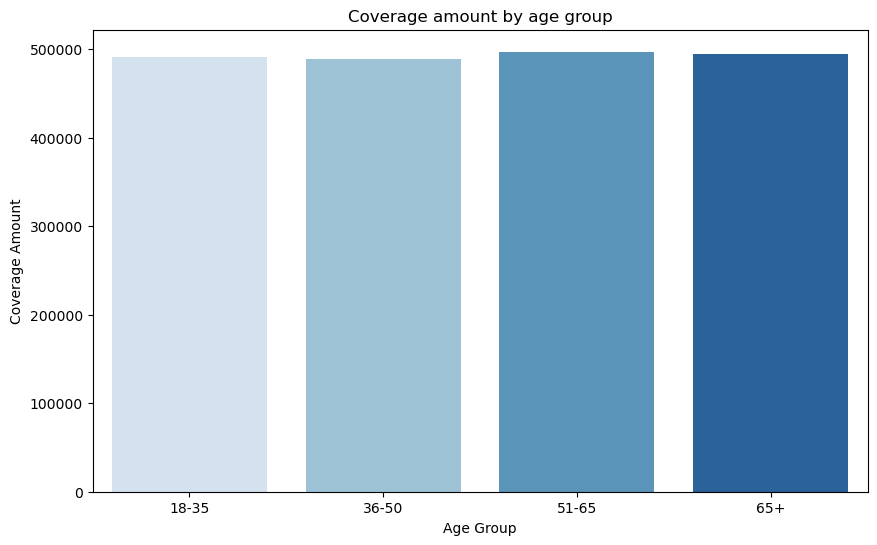

In [7]:
df['Age Group'] = pd.cut(df['Age'],
                         bins=[18,35,50,65,100],
                         labels=['18-35','36-50','51-65','65+'])
premium_by_age = df.groupby('Age Group')['Coverage Amount'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=premium_by_age, x='Age Group',y='Coverage Amount',palette='Blues')
plt.title('Coverage amount by age group')
plt.xlabel('Age Group')
plt.ylabel('Coverage Amount')
plt.show()

C:\Users\adigo\AppData\Local\Temp\ipykernel_4680\3945552933.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  premium_by_age = df.groupby('Age Group')['Income Level'].mean().reset_index()
C:\Users\adigo\AppData\Local\Temp\ipykernel_4680\3945552933.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=premium_by_age, x='Age Group',y='Income Level',palette='Blues')


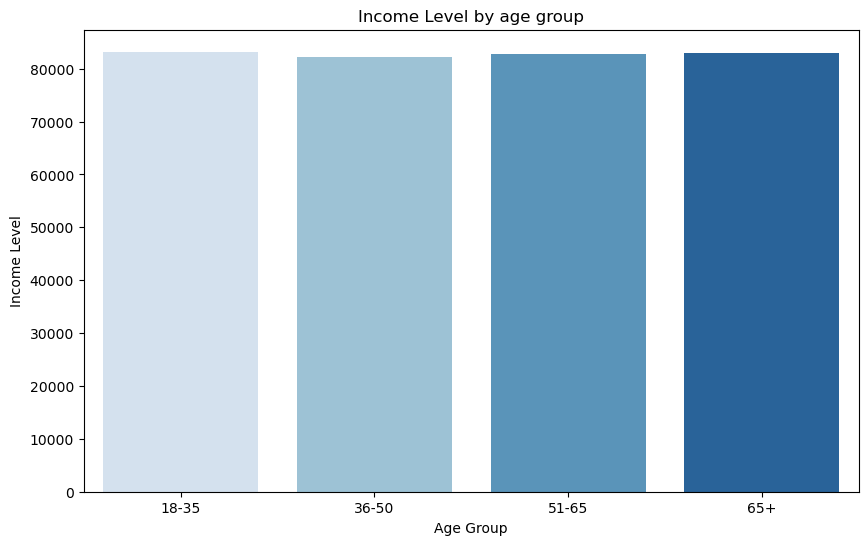

In [8]:
premium_by_age = df.groupby('Age Group')['Income Level'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=premium_by_age, x='Age Group',y='Income Level',palette='Blues')
plt.title('Income Level by age group')
plt.xlabel('Age Group')
plt.ylabel('Income Level')
plt.show()

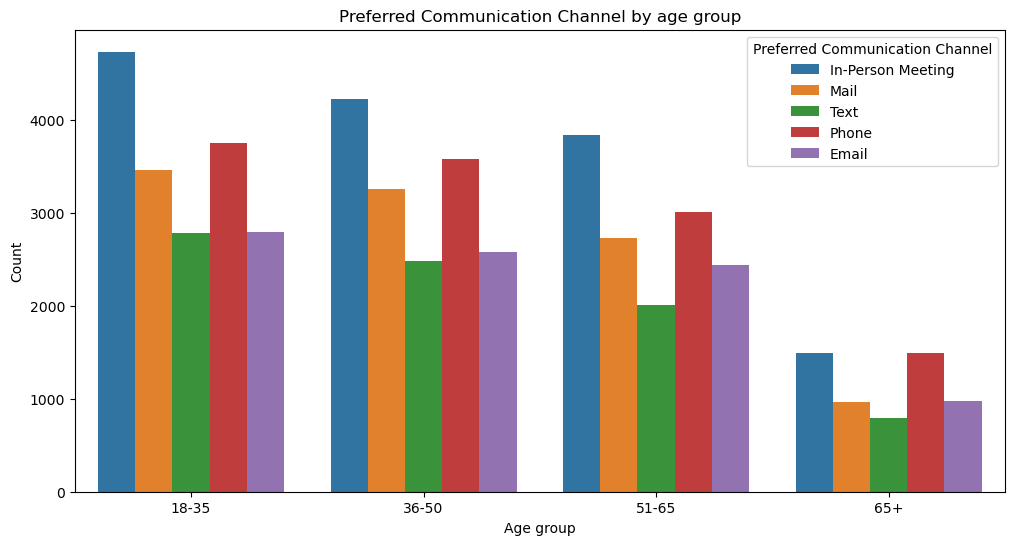

In [9]:
# Preferred Communication Channel by age group
plt.figure(figsize=(12,6))

sns.countplot(data=df, x='Age Group', hue='Preferred Communication Channel')
plt.title('Preferred Communication Channel by age group')
plt.xlabel('Age group')
plt.ylabel('Count')
plt.show()

In [10]:
df['Young People'] = np.where(df['Age'] < 35, 'Under 35', '35 and over')
print(df['Young People'].value_counts())

Young People
35 and over    36914
Under 35       16589
Name: count, dtype: int64


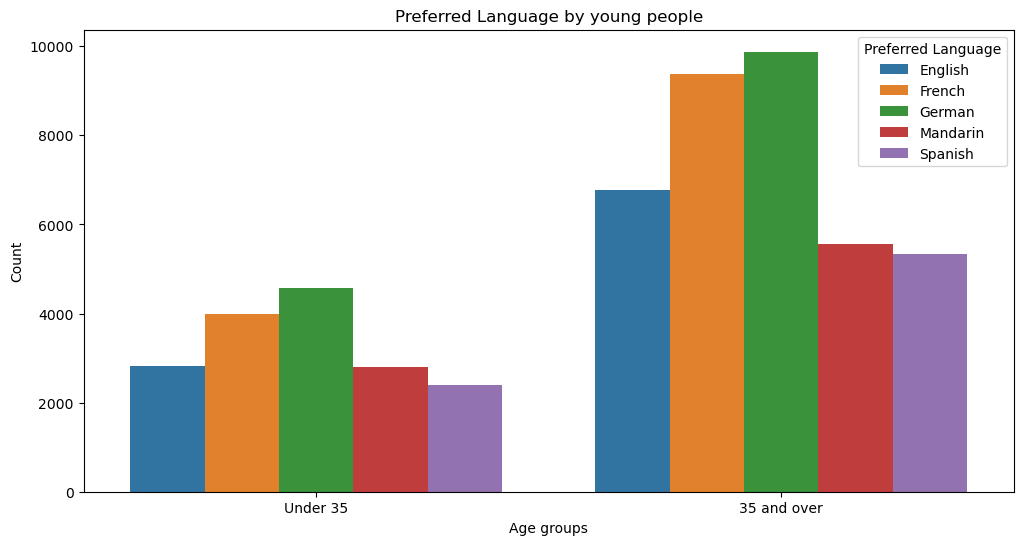

In [11]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Young People', hue='Preferred Language')
plt.title('Preferred Language by young people')
plt.xlabel('Age groups')
plt.ylabel('Count')
plt.show()

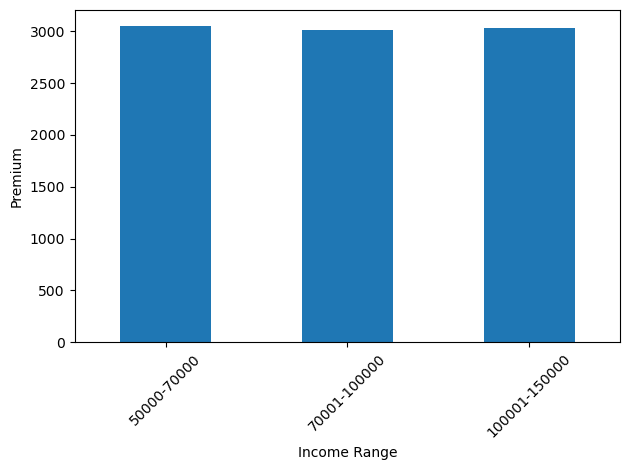

In [15]:
df['Income bracket'] = pd.cut(df['Income Level'],
                                bins=[50000,70000,100000,150000,200000,500000,1000000],
                                labels=['50000-70000','70001-100000','100001-150000','150001-200000','200001-500000','500000+'])
df['Premium range'] = pd.cut(df['Premium Amount'],
                             bins=[500,1000,2000,3000,4000,5000],
                             labels=['500-1000','1001-2000','2001-3000','3001-4000','4001-5000'])

avg_premium = (
    df.groupby("Income bracket", observed=True)['Premium Amount']
      .mean()
)

avg_premium.plot(kind='bar')
plt.xlabel('Income Range')
plt.ylabel('Premium')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


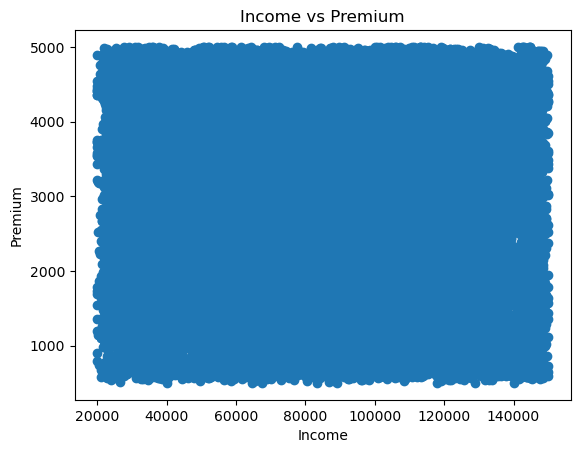

In [ ]:
plt.scatter(df["Income Level"], df["Premium Amount"])
plt.xlabel("Income")
plt.ylabel("Premium")
plt.title("Income vs Premium")
plt.show()